In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

movies = pd.read_csv(r"D:\Program Files\movie_analysis\tmdb_5000_movies.csv")

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [2]:
# 1. 查看缺失值
print(movies.isnull().sum())

# 2. 去掉预算/票房为0的无效数据
movies = movies[(movies['budget'] > 0) & (movies['revenue'] > 0)]

# 3. 提取上映年份
movies['release_year'] = pd.to_datetime(movies['release_date']).dt.year

# 4. 计算投资回报率（ROI = 票房/预算）
movies['roi'] = movies['revenue'] / movies['budget']

# 清洗后的数据量
print(f"清洗后剩余电影数量：{len(movies)}")

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64
清洗后剩余电影数量：3229


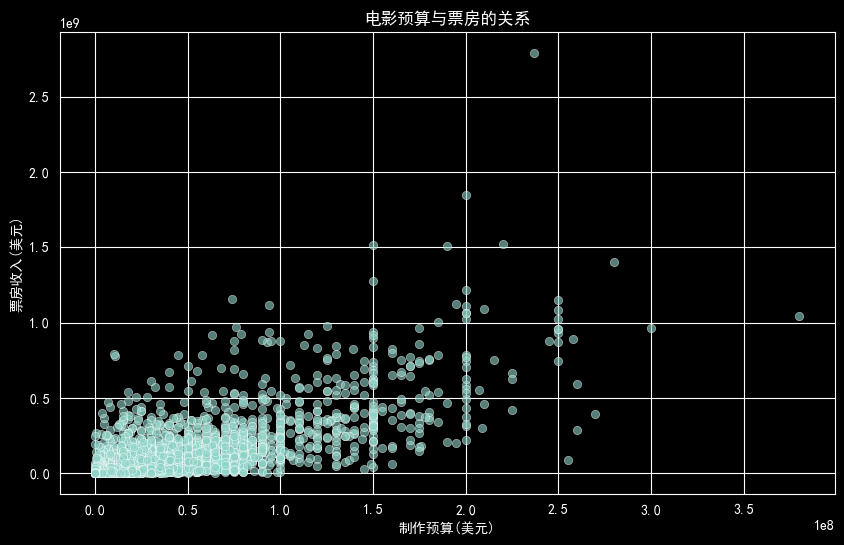

预算与票房的相关系数：0.71


In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='revenue', data=movies, alpha=0.6)
plt.title('电影预算与票房的关系')
plt.xlabel('制作预算(美元)')
plt.ylabel('票房收入(美元)')
plt.savefig('budget_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

corr = movies['budget'].corr(movies['revenue'])
print(f"预算与票房的相关系数：{corr:.2f}")

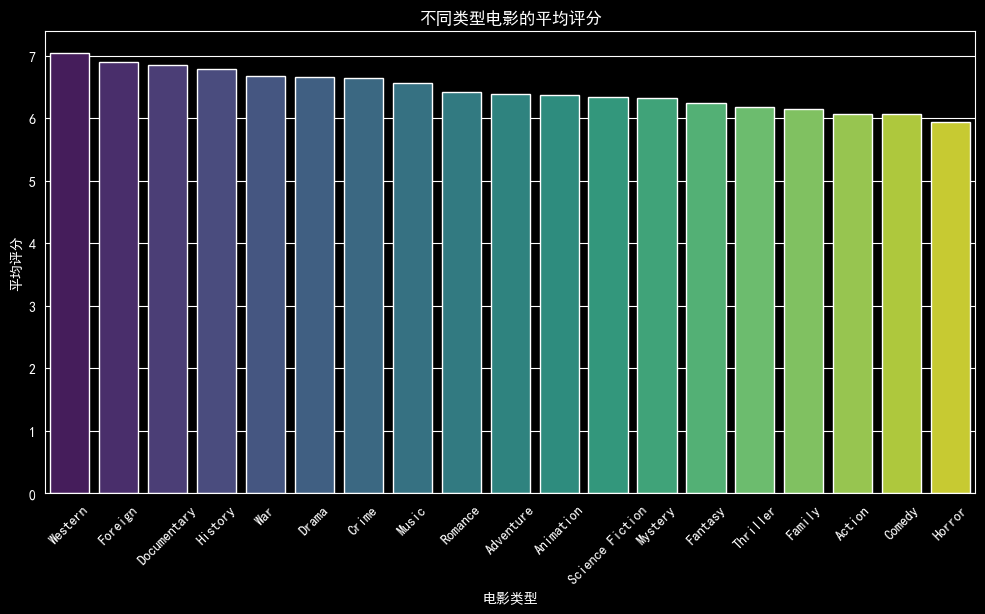

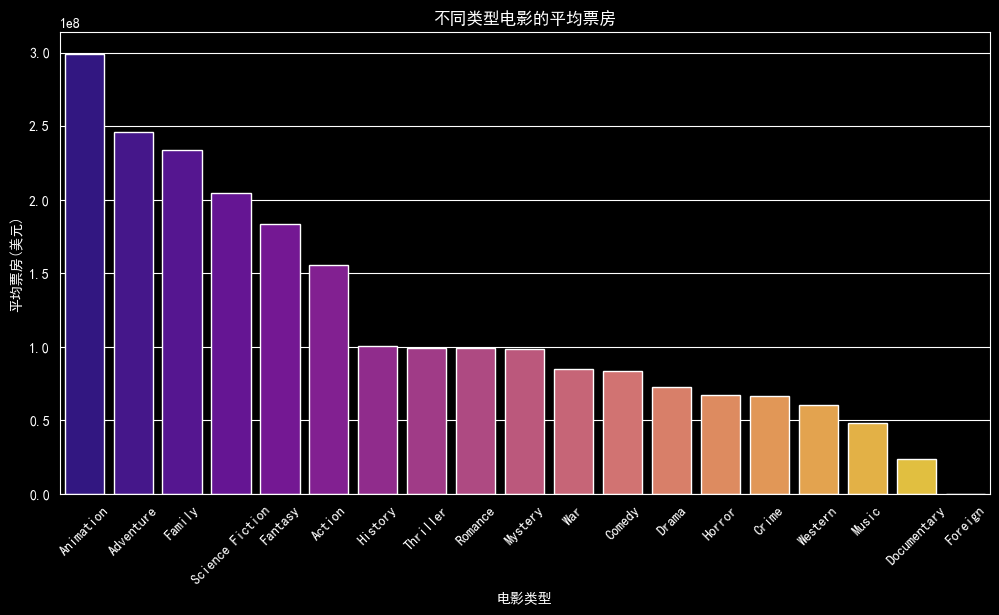

In [5]:
# 处理电影类型字段
import json
def extract_genres(genres_str):
    genres = json.loads(genres_str)
    return [g['name'] for g in genres]

movies['genres_list'] = movies['genres'].apply(extract_genres)

# 把类型展开(一部电影可能有多个类型,取第一个类型简化分析)
movies['main_genre'] = movies['genres_list'].str[0]

# 统计不同类型电影的平均评分和票房
genre_stats = movies.groupby('main_genre').agg({
    'vote_average': 'mean',
    'revenue': 'mean'
}).reset_index()

# 可视化：不同类型的平均评分
plt.figure(figsize=(12, 6))
sns.barplot(x='main_genre',
            y='vote_average',
            data=genre_stats.sort_values('vote_average', ascending=False),
            palette='viridis',
            hue='main_genre',
            legend=False)
plt.title('不同类型电影的平均评分')
plt.xlabel('电影类型')
plt.ylabel('平均评分')
plt.xticks(rotation=45)
plt.savefig('genre_rating.png', dpi=300, bbox_inches='tight')
plt.show()

# 可视化：不同类型的平均票房
plt.figure(figsize=(12, 6))
sns.barplot(x='main_genre',
            y='revenue',
            data=genre_stats.sort_values('revenue', ascending=False),
            palette='plasma',
            hue='main_genre',
            legend=False)
plt.title('不同类型电影的平均票房')
plt.xlabel('电影类型')
plt.ylabel('平均票房(美元)')
plt.xticks(rotation=45)
plt.savefig('genre_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

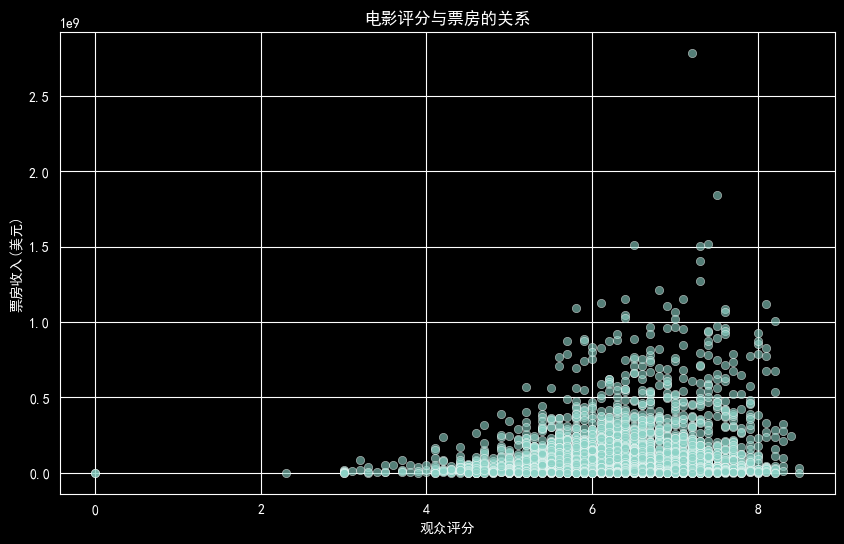

评分与票房的相关系数：0.19


In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='vote_average', y='revenue', data=movies, alpha=0.6)
plt.title('电影评分与票房的关系')
plt.xlabel('观众评分')
plt.ylabel('票房收入(美元)')
plt.savefig('rating_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

corr_rating_revenue = movies['vote_average'].corr(movies['revenue'])
print(f"评分与票房的相关系数：{corr_rating_revenue:.2f}")

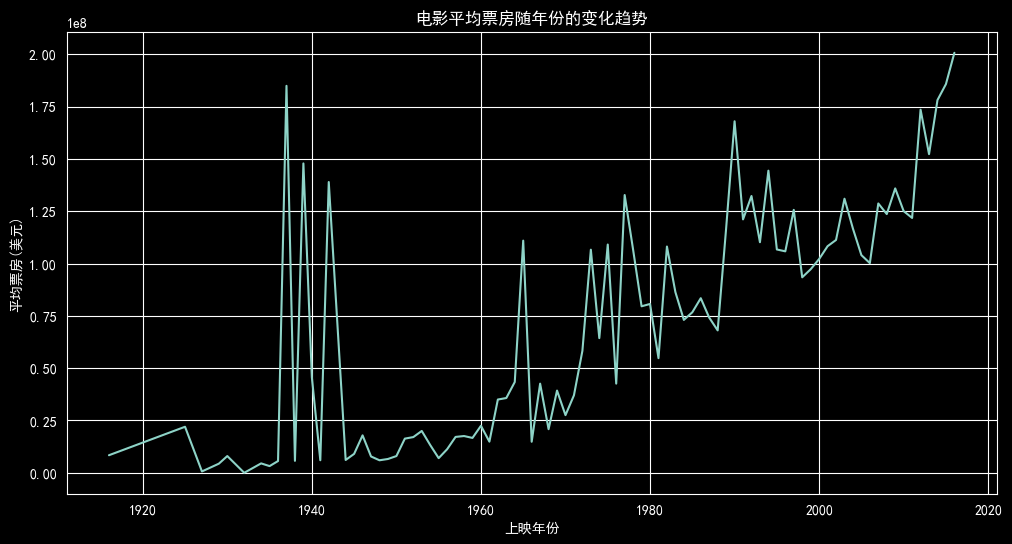

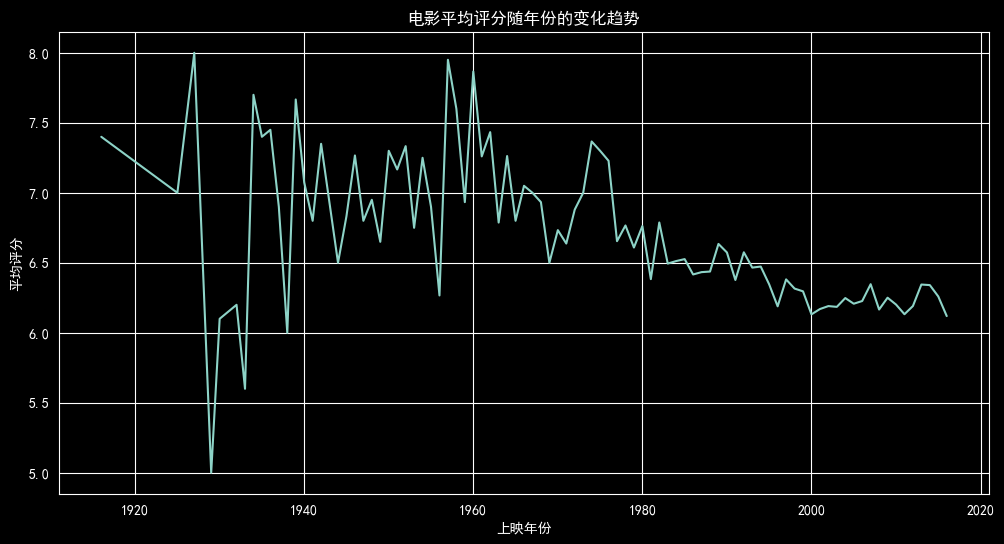

In [7]:
# 按年份统计平均票房和评分
year_stats = movies.groupby('release_year').agg({
    'revenue': 'mean',
    'vote_average': 'mean'
}).reset_index()

# 票房趋势
plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='revenue', data=year_stats)
plt.title('电影平均票房随年份的变化趋势')
plt.xlabel('上映年份')
plt.ylabel('平均票房(美元)')
plt.savefig('year_revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# 评分趋势
plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='vote_average', data=year_stats)
plt.title('电影平均评分随年份的变化趋势')
plt.xlabel('上映年份')
plt.ylabel('平均评分')
plt.savefig('year_rating_trend.png', dpi=300, bbox_inches='tight')
plt.show()